# Visualize comparisons

This notebook visualizes some comparisons the two different algorithms of Musclemap that can segment thighs

In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd

In [3]:
thigh_left_grac_dataset_str = '../eval_notebooks/MuscleMap_results_thigh/df_l_gracilis_thigh.csv'
body_left_grac_dataset_str = '../eval_notebooks/MuscleMap_results_WB/df_l_gracilis.csv'

In [24]:
#!pwd

In [6]:
thigh_left_grac_dataset = pd.read_csv('../MuscleMap_results_thigh/df_l_gracilis_thigh.csv')
body_left_grac_dataset = pd.read_csv('../MuscleMap_results_WB/df_l_gracilis.csv')

In [18]:
thigh_left_grac_dataset.head(3)

,Unnamed: 0,image,pred_label,L_gracilis_lower_dice:,L_gracilis_lower_Hausdorff:,L_gracilis_jaccard,L_gracilis_volume_similarity,L_gracilis_falseNegative,L_gracilis_falsePostivie
0,0,HV001_1/SegmentationMasks/combined_gt_stack1.mha,HV001_1_FATFRACTION_stack1_dseg.nii.gz,0.764219,7.000000,0.618410,-1.440162,0.241125,0.000108
1,1,HV001_1/SegmentationMasks/combined_gt_stack2.mha,HV001_1_FATFRACTION_stack2_dseg.nii.gz,0.818813,8.124038,0.693212,-1.440162,0.194773,0.000123
2,2,HV001_2/SegmentationMasks/combined_gt_stack1.mha,HV001_2_FATFRACTION_stack1_dseg.nii.gz,0.782853,5.000000,0.643187,-1.440162,0.243911,0.000089


In [25]:
len(thigh_left_grac_dataset)

54

## we know dice will be between 0 to 1, as will jaccard, false positive and false negatives
### so let's visualize them in a cross in a circle or square

There is the caveat that false negative and positive should be as low as possible, while DIce and Jaccaard should be as high as possible. Therefore we will use 1 - false negative and 1 - false positive to keep a simple visual where bigger is better

In [19]:
thigh_left_grac_dataset['one_minus_falseNegative'] = 1 - thigh_left_grac_dataset['L_gracilis_falseNegative'] 
thigh_left_grac_dataset['one_minus_falsePositive'] = 1 - thigh_left_grac_dataset['L_gracilis_falsePostivie'] 

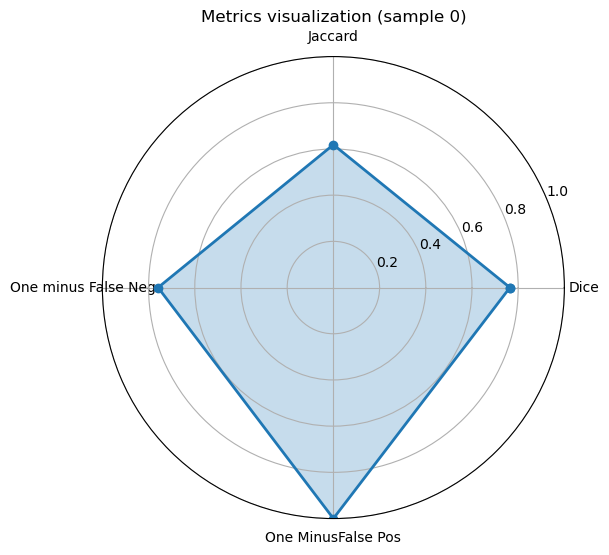

In [22]:
# look at a single row
# Select columns
metrics = [
    "L_gracilis_lower_dice:",
    "L_gracilis_jaccard",
    "one_minus_falseNegative",
    "one_minus_falsePositive"
]

# Pick one row (example)
row = thigh_left_grac_dataset.iloc[0]

values = row[metrics].values.astype(float)

# Close the loop
values = np.append(values, values[0])

# Angles for 4 axes
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
angles = np.append(angles, angles[0])

# Plot
fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

ax.plot(angles, values, 'o-', linewidth=2)
ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(["Dice", "Jaccard", "One minus False Neg", "One MinusFalse Pos"])

ax.set_ylim(0, 1)

plt.title("Metrics visualization (sample 0)")
plt.show()

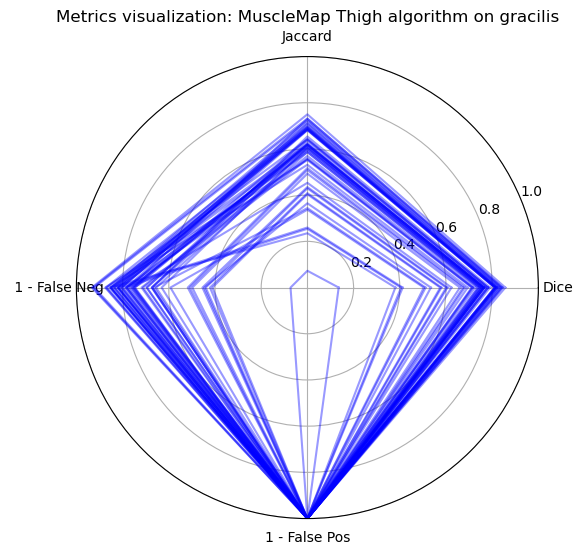

In [32]:

metrics = [
    "L_gracilis_lower_dice:",
    "L_gracilis_jaccard",
    "one_minus_falseNegative",
    "one_minus_falsePositive"
]

# Create angles
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
angles = np.append(angles, angles[0])

# Create figure + polar axis
fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

# Plot multiple samples
for i in range(54):
    row = thigh_left_grac_dataset.iloc[i]
    values = row[metrics].values.astype(float)
    values = np.append(values, values[0])
    ax.plot(angles, values, color="blue", alpha=0.4)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(["Dice", "Jaccard", " 1 - False Neg", "1 - False Pos"])
ax.set_ylim(0, 1)

plt.title("Metrics visualization: MuscleMap Thigh algorithm on gracilis")
plt.show()

## What does this tell us? 

With the thigh algorithm, we never get false positives...the segmentation is always inside the ground truth. This is an important note...let's compare to the whole body algorithm

In [34]:
#body_left_grac_dataset.head(3)

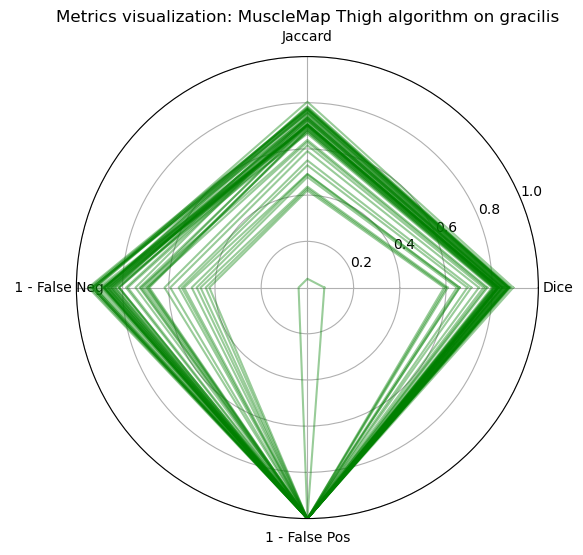

In [35]:
body_left_grac_dataset['one_minus_falseNegative'] = 1 - body_left_grac_dataset['L_gracilis_falseNegative'] 
body_left_grac_dataset['one_minus_falsePositive'] = 1 - body_left_grac_dataset['L_gracilis_falsePostivie']
metrics = [
    "L_gracilis_lower_dice:",
    "L_gracilis_jaccard",
    "one_minus_falseNegative",
    "one_minus_falsePositive"
]

# Create angles
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
angles = np.append(angles, angles[0])

# Create figure + polar axis
fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

# Plot multiple samples
for i in range(54):
    row = body_left_grac_dataset.iloc[i]
    values = row[metrics].values.astype(float)
    values = np.append(values, values[0])
    ax.plot(angles, values, color="green", alpha=0.4)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(["Dice", "Jaccard", " 1 - False Neg", "1 - False Pos"])
ax.set_ylim(0, 1)

plt.title("Metrics visualization: MuscleMap Body algorithm on gracilis")
plt.show()

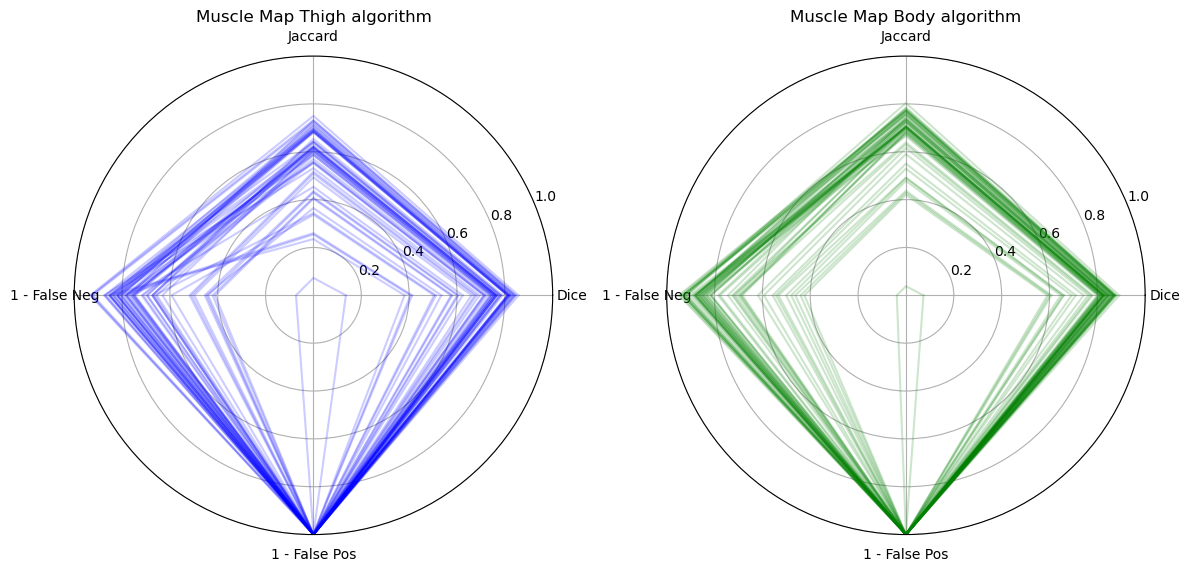

In [37]:
import numpy as np
import matplotlib.pyplot as plt

metrics = [
    "L_gracilis_lower_dice:",
    "L_gracilis_jaccard",
    "one_minus_falseNegative",
    "one_minus_falsePositive"
]

# Angles (shared)
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
angles = np.append(angles, angles[0])

# Create ONE figure with TWO polar subplots
fig, axes = plt.subplots(1, 2, figsize=(12,6), subplot_kw=dict(polar=True))

# ---- LEFT: thigh ----
ax = axes[0]
for i in range(54):
    row = thigh_left_grac_dataset.iloc[i]
    values = row[metrics].values.astype(float)
    values = np.append(values, values[0])
    ax.plot(angles, values, color="blue", alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(["Dice", "Jaccard", "1 - False Neg", "1 - False Pos"])
ax.set_ylim(0, 1)
ax.set_title("Muscle Map Thigh algorithm")

# ---- RIGHT: body ----
ax = axes[1]
for i in range(54):
    row = body_left_grac_dataset.iloc[i]
    values = row[metrics].values.astype(float)
    values = np.append(values, values[0])
    ax.plot(angles, values, color="green", alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(["Dice", "Jaccard", "1 - False Neg", "1 - False Pos"])
ax.set_ylim(0, 1)
ax.set_title( "Muscle Map Body algorithm")

plt.tight_layout()
plt.tight_layout()
plt.savefig("gracilis_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

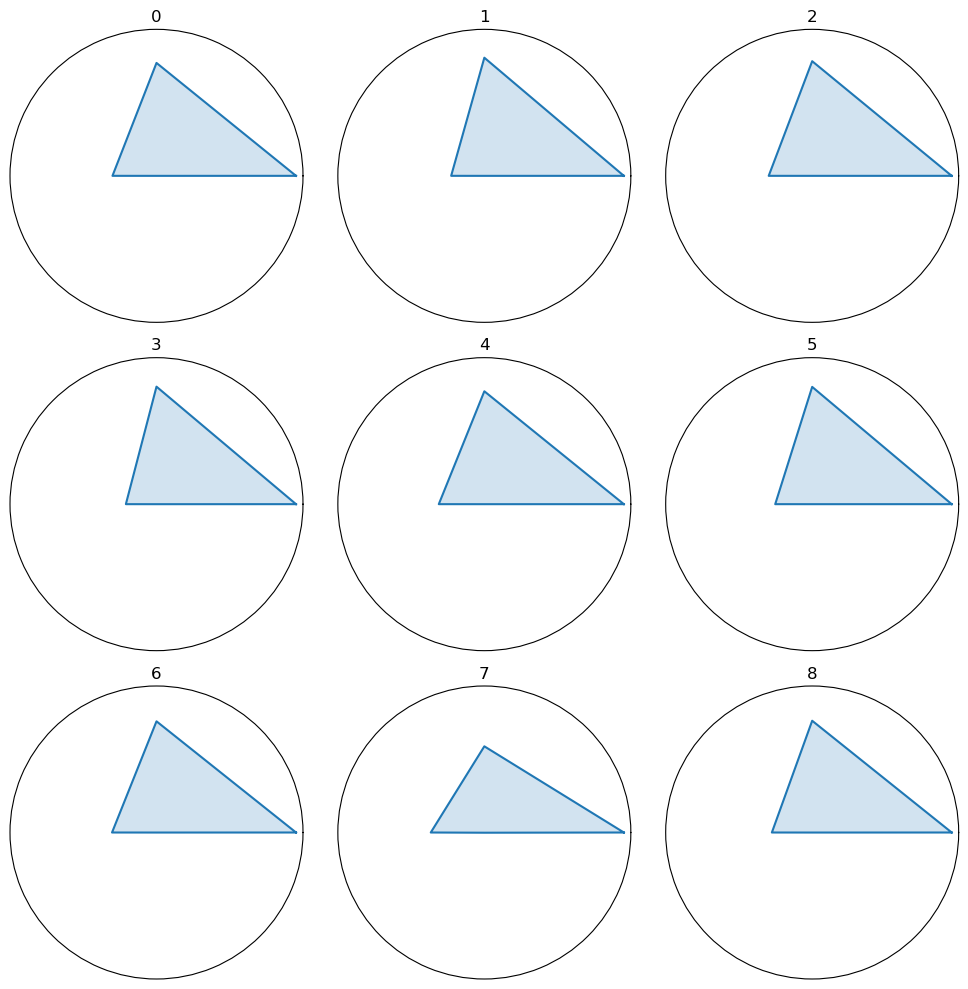

In [14]:
fig, axes = plt.subplots(3, 3, subplot_kw=dict(polar=True), figsize=(10,10))

for i, ax in enumerate(axes.flat):
    if i >= len(thigh_left_grac_dataset):
        break
        
    row = thigh_left_grac_dataset.iloc[i]
    values = row[metrics].values.astype(float)
    values = np.append(values, values[0])
    
    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{i}")

plt.tight_layout()
plt.show()